<p class="h1">ECE 447 - Notebook 15</p>
<p class="h2">Neural Networks</p>

In [12]:
import torch
import torch.nn.functional as F
import torchvision
from tqdm import tqdm
from torchvision.transforms import v2

import matplotlib.pyplot as plt

In [13]:
params = {
    # "model": "DenseModel",
    "model": "CNNModel",
    ### data
    "dataset": "MNIST",
    "data_dim": 784,
    "num_classes": 10,
    ### data loader
    "shuffle": True,
    "batch_size": 128,
    "num_workers": 4,
    ### optimizer
    "optimizer_name": "AdamW",
    "optimizer_lr": 1e-3,
    "optimizer_weight_decay": 0,
    ### network
    "net_hidden_dim": 50,
    ### optimizer_scheduler
    "optimizer_scheduler": "StepLR",
    "optimizer_scheduler_gamma": None,
    "optimizer_scheduler_patience": None,
    "optimizer_scheduler_tmax": None,
    "optimizer_scheduler_stepsize": 10,
    "optimizer_scheduler_gamma": 0.5,
    ### loss
    "loss_name": "CrossEnt",
    ### train related
    "num_epochs": 10,
    "tqdm_prints_disable": False,
    "disable_inner_loop": False,
    }

# device = "cpu" # for cpu
# device = "cuda:0" # for nvidia
device = "mps:0" # for mac with gpu

In [14]:
# load datasets

if params["dataset"] == "MNIST":
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
    dataset = torchvision.datasets.MNIST("data", train=True, transform=transform, download=True)
    train_dataset = torch.utils.data.Subset(dataset, range(50000))
    test_dataset = torch.utils.data.Subset(dataset, range(50000, len(dataset)))

elif params["dataset"] == "RotatedMNIST":
    rotation_angle = params.get('rotation_angle', 45)  # default 45 degrees
    transform = v2.Compose([
        v2.ToImage(), 
        v2.ToDtype(torch.float32, scale=True),
        v2.RandomRotation(degrees=rotation_angle)
    ])
    dataset = torchvision.datasets.MNIST("data", train=True, transform=transform, download=True)
    train_dataset = torch.utils.data.Subset(dataset, range(50000))
    test_dataset = torch.utils.data.Subset(dataset, range(50000, len(dataset)))

elif params["dataset"] == "CIFAR10":
    transform = v2.Compose([
        v2.ToImage(), 
        v2.ToDtype(torch.float32, scale=True),
    ])
    dataset = torchvision.datasets.CIFAR10(
        "data", train=True, transform=transform, download=True
        )
    train_dataset = torch.utils.data.Subset(dataset, range(40000))
    test_dataset = torch.utils.data.Subset(dataset, range(40000, len(dataset)))


In [15]:
# create loaders

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    shuffle=params["shuffle"],
    batch_size=params["batch_size"],
    num_workers=params["num_workers"],
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, shuffle=False, batch_size=1, num_workers=params["num_workers"],
)

In [16]:
# define the model class

class DenseModel(torch.nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DenseModel, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, 512)
        self.fc2 = torch.nn.Linear(512, 512)
        self.fc3 = torch.nn.Linear(512, 100)
        self.fc4 = torch.nn.Linear(100, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = F.relu(x)
        x = self.fc4(x)
        output = F.log_softmax(x, dim=1)
        return output
    
class CNNModel(torch.nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 32, 3, 1)
        self.conv2 = torch.nn.Conv2d(32, 64, 3, 1)
        self.fc1 = torch.nn.Linear(9216, 128)
        self.fc2 = torch.nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

class AEModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(AEModel, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # encoder
        z = self.relu(self.fc1(x))
        # decoder
        xhat = self.fc1(z)
        return xhat, z

In [17]:
# build the network

if params["model"] == "DenseModel":
    net = DenseModel(input_dim=params["data_dim"], num_classes=params["num_classes"])
elif params["model"] == "CNNModel":
    net = CNNModel(num_classes=params["num_classes"])

net.to(device)

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [18]:
# setup optimizer
if params["optimizer_name"] == "AdamW":
    optimizer = torch.optim.AdamW(
        net.parameters(),
        lr=params["optimizer_lr"],
        weight_decay=params["optimizer_weight_decay"],
    )
elif params["optimizer_name"] == "Adam":
    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=params["optimizer_lr"],
        weight_decay=params["optimizer_weight_decay"],
    )
elif params["optimizer_name"] == "SGD":
    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=params["optimizer_lr"],
        weight_decay=params["optimizer_weight_decay"],
    )

In [19]:
# setup lr scheduler
  
if params["optimizer_scheduler"] == "ReduceLROnPlateau":
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        factor=params["optimizer_scheduler_gamma"],
        patience=params["optimizer_scheduler_patience"],
        mode="min",
    )
elif params["optimizer_scheduler"] == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=params["optimizer_scheduler_tmax"]
    )
elif params["optimizer_scheduler"] == "StepLR":
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=params["optimizer_scheduler_stepsize"],
        gamma=params["optimizer_scheduler_gamma"],
    )
else:
    raise ValueError(f"Scheduler name is not implemented!")

In [20]:
# create loss function to be used to train your network

if params["loss_name"] == "MSE":
    criterion = torch.nn.MSELoss()
elif params["loss_name"] == "L1loss":
    criterion = torch.nn.L1Loss()
elif params["loss_name"] == "SmoothL1Loss":
    criterion = torch.nn.SmoothL1Loss()
elif params["loss_name"] == "CrossEnt":
    criterion =  torch.nn.CrossEntropyLoss()

In [21]:
# train loop

print("start training dnn.")

net.train()

step = 0
loss_all = list()
step_all = list()
train_acc_all = list()
for epoch in tqdm(
    range(params["num_epochs"]), disable=params["tqdm_prints_disable"]
):
    net.train()

    for idx, (x, y) in tqdm(enumerate(train_loader), disable=params["disable_inner_loop"]): # x is the image, y is its label

        step += 1

        # sent data into device (e.g., gpu)
        if params["model"] == "DenseModel":
            x = torch.flatten(x, 1)
            
        x = x.to(device)
        y = y.to(device)

        # forward map prediction
        yhat = net(x)

        # compute the loss
        loss = criterion(yhat, y)

        # reset the gradients
        optimizer.zero_grad(set_to_none=True)
        # backward to compute the gradients
        loss.backward()

        # take a gradient descent step
        optimizer.step()

        correct_indicators = yhat.max(1)[1].data == y
        train_acc = correct_indicators.sum().item() / y.shape[0]
        
        if step %400 == 0:
            print("train_acc", train_acc)   

        loss_all.append(loss.item())
        step_all.append(step)
        train_acc_all.append(train_acc)

    # scheduler
    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(loss)
    else:
        scheduler.step()



start training dnn.


391it [00:03, 125.98it/s]:00<?, ?it/s]
 10%|█         | 1/10 [00:03<00:28,  3.14s/it]

train_acc 0.9609375


391it [00:03, 126.19it/s]
 20%|██        | 2/10 [00:06<00:25,  3.13s/it]

train_acc 0.9921875


...

391it [00:03, 128.12it/s]
 80%|████████  | 8/10 [00:24<00:06,  3.06s/it]

train_acc 1.0


391it [00:03, 129.81it/s]
 90%|█████████ | 9/10 [00:27<00:03,  3.05s/it]

train_acc 1.0


391it [00:03, 121.58it/s]
100%|██████████| 10/10 [00:30<00:00,  3.09s/it]


In [22]:
def evaluate_the_model(dataloader, net, device="cpu"):

    with torch.no_grad():
        num_correct = 0
        num_total = 0
        for idx, (x, y) in tqdm(enumerate(dataloader), disable=True):

            if params["model"] == "DenseModel":
                x = torch.flatten(x, 1)
            x = x.to(device)
            y = y.to(device)

            yhat = net(x)

            correct_indicators = yhat.max(1)[1].data == y
            num_correct += correct_indicators.sum().item()
            num_total += y.size()[0]

    acc = num_correct / num_total

    return acc

CNNModel


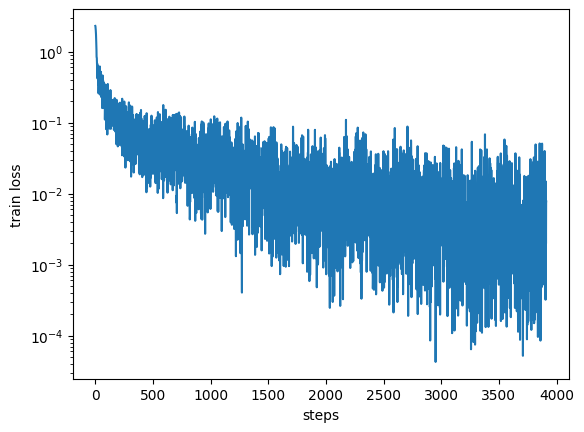

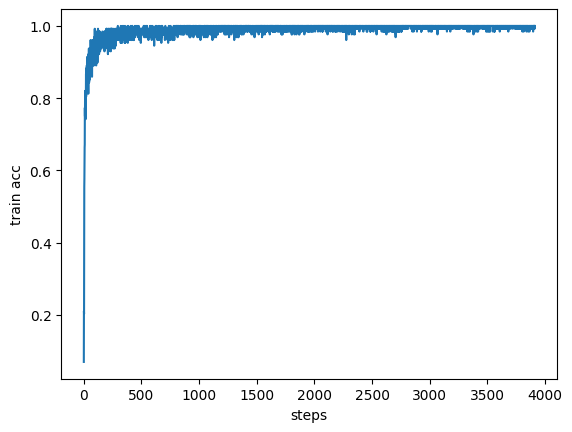

In [23]:
print(params["model"])

plt.figure()
plt.plot(step_all, loss_all)
plt.xlabel("steps")
plt.ylabel("train loss")
plt.yscale("log")
plt.show()

plt.figure()
plt.plot(step_all, train_acc_all)
plt.xlabel("steps")
plt.ylabel("train acc")
plt.show()

In [24]:
print(params["model"])

train_acc = evaluate_the_model(train_loader, net, device)
print("train", train_acc)

test_acc = evaluate_the_model(test_loader, net, device)
print("test", test_acc)

CNNModel
train 0.99656
test 0.987
